# **Reaparición en el Cáncer de Tiroides**

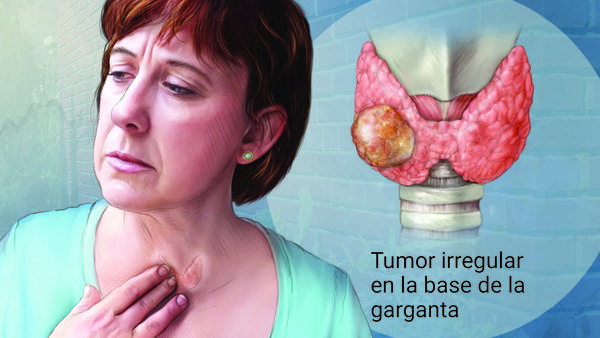

## **Sobre este dataset**
> " This dataset focuses on thyroid cancer recurrence after Radioactive Iodine (RAI) therapy. It contains 383 patient records with 13 key attributes, including age, gender, cancer staging, pathology type, risk classification, treatment response, and recurrence status. The data is valuable for predicting cancer recurrence, understanding risk factors, and evaluating treatment outcomes. "

[Este dataset se enfoca en la reaparición del cáncer de tiroides después del tratamiento con terapia de radioyodo. Este contiene 383 datos de pacientes con 13 columnas de atributos, incluyendo: edad, género, etapa del cáncer, tipo de patología, clasificación de riesgo, respuesta al tratamiento, y estado de reaparicipón ("Si"/"No"). Estos datos son valiosos para predecir la reaparición del cáncer, entender factores de riesgo, y evaluar los resultados del tratamiento.]

(Thyroid Cancer Recurrence Dataset, 2025)

---

## **Acerca de los tipos de cáncer en este dataset**

* **Carcinoma Papilar**: Este es el tipo de cáncer más común, resultando así —por lo general— en un buen pronóstico si se detecta a tiempo. Crece lento, pero puede diseminarse a ganglios linfáticos del cuello.

* **Carcinoma Micropapilar**: Tumor de bajo riesgo y frecuencia. Este cáncer es la variante de ≤1cm del carcinoma papilar. Más del 90% no progresa ni causa sintomas o muerte, incluso sin tratamiento. Si bien < 1 - 2% puede reaparecer o metastizar, la identificación temprana y monitorización sigue siendo clave por riesgo de diseminación.

* **Carcinoma Folicular**: Más agresivo que el carcinoma papilar. Se origina en las células foliculares* causando un tumor y suele metastizar por sangre a pulmones y huesos. A pesar de lo anteriormente mencionado, presenta buen pronóstico si se detecta a tiempo.

* **Carcinoma de células de Hürthle**: Poco frecuente y con tendencia a ser más agresivo que el carcinoma folicular clásico. Se diferencia por una acumulación de mitocondrias. Este tipo de cáncer tiene tendencia a ser más resistente al tratamiento del yodo radioactivo.

---
### Diccionario para este dataset:
* **Carcinoma**: Tipo de cáncer. Se origina en las células epiteliales.
* **Células epiteliales**: Estas células tienen la función de revestimiento.
* **Célula folicular**: Tienen la función principal de síntesis de hormonas tiroideas (T3/T4). Captan yodo y producen tiroglobulina. Son células epiteliales, pero no todas las epiteliales son foliculares.

* **Adenopatía**: Inflamación o aumento de tamaño de los ganglios linfáticos.



In [ ]:
#Importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

palette = sns.color_palette("Set2")

In [ ]:
#cargamos nuestro Token de Kaggle
from google.colab import files
files.upload()

#Iniciamos la instalación de la API para cargar el dataset
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d aneevinay/thyroid-cancer-recurrence-dataset
!ls

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aneevinay/thyroid-cancer-recurrence-dataset
License(s): CC-BY-NC-SA-4.0
kaggle.json  sample_data  thyroid-cancer-recurrence-dataset.zip


In [ ]:
!unzip -o thyroid-cancer-recurrence-dataset.zip #otra opcion es !unzip -o , la cual sobrescribe automáticamente.

Archive:  thyroid-cancer-recurrence-dataset.zip
  inflating: filtered_thyroid_data.csv  


In [ ]:
df = pd.read_csv('filtered_thyroid_data.csv')
df.head(10)

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
5,52,M,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Indeterminate,No
6,41,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
7,46,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
8,51,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No


# 1. Análisis exploratiorio del dataset

In [ ]:
#Atributos de las columnas
print("Atributos de las columnas\n", df.columns.tolist())

#Verificar tipos de datos
print("\nTipos de datos originales:\n", df.dtypes)

#Identificar valores nulos
null_counts = df.isnull().sum()
print("\nCantidad de nulos por columna:\n", null_counts)

print("\nDescribir datos numéricos:")
print(df.describe())

Atributos de las columnas
 ['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']

Tipos de datos originales:
 Age                 int64
Gender             object
Hx Radiothreapy    object
Adenopathy         object
Pathology          object
Focality           object
Risk               object
T                  object
N                  object
M                  object
Stage              object
Response           object
Recurred           object
dtype: object

Cantidad de nulos por columna:
 Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

Describir datos numéricos:
              Age
count  383.000000
mean    40.866841
std     15.134494
min     15.000000
25%     29.000000
50%  

In [ ]:
# Clasificación de las variables

numericas_continuas = ['Age']

categoricas_nominales = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Recurred']
categoricas_ordinales = ['Risk', 'T', 'N', 'M', 'Stage', 'Response']

print("\nClasificación de variables:")
print(f"Numéricas continuas: {numericas_continuas}")
print(f"Categóricas nominales: {categoricas_nominales}")
print(f"Categóricas ordinales: {categoricas_ordinales}")


Clasificación de variables:
Numéricas continuas: ['Age']
Categóricas nominales: ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Recurred']
Categóricas ordinales: ['Risk', 'T', 'N', 'M', 'Stage', 'Response']


In [ ]:
for col in categoricas_nominales:
    df[col] = df[col].astype("category")

# Convertir género a binario con etiquetas
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})
df['Gender'] = df['Gender'].astype(int)

# Convertir Recurred a binario con etiquetas
df['Recurred'] = df['Recurred'].map({'yes': 1, 'no': 0}) #1 si hubo reaparición ; 0 no hubo reaparición
df['Recurred'] = df['Recurred'].astype(int)

#Verificar tipos de datos nuevamente
print("\nTipos de datos:\n", df.dtypes)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

# 2.2 Análisis estadístico

Outliers en la variable Age:
Empty DataFrame
Columns: [Age]
Index: []


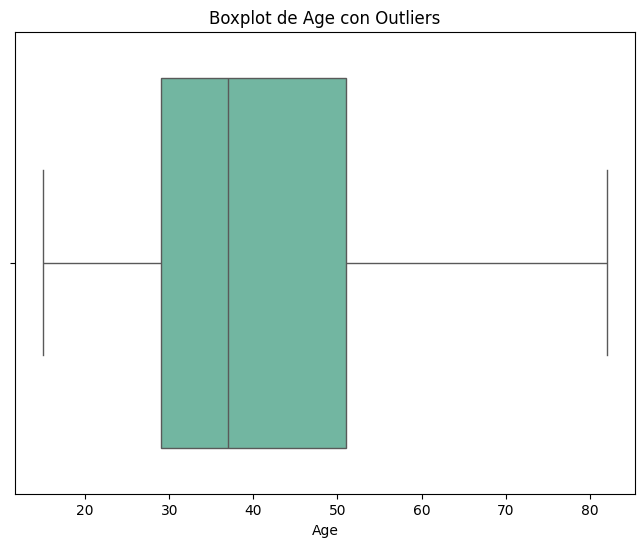

In [ ]:
# Calcular el rango intercuartílico (IQR) para cada variable numérica
for col in numericas_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para identificar outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers en la variable {col}:\n{outliers[[col]]}")

    # Visualizar los outliers
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col], palette='Set2')
    plt.title(f'Boxplot de {col} con Outliers')
    plt.show()

La cantidad de pacientes en el dataset es: 383

Porcentaje de recurrencia del cáncer de tiroides:
Recurred
No     71.801567
Yes    28.198433
Name: proportion, dtype: float64

Porcentaje de tipo de patología por recurrencia:
Pathology  Follicular  Hurthel cell  Micropapillary  Papillary
Recurred                                                      
No           5.818182      5.090909       17.454545  71.636364
Yes         11.111111      5.555556        0.000000  83.333333 



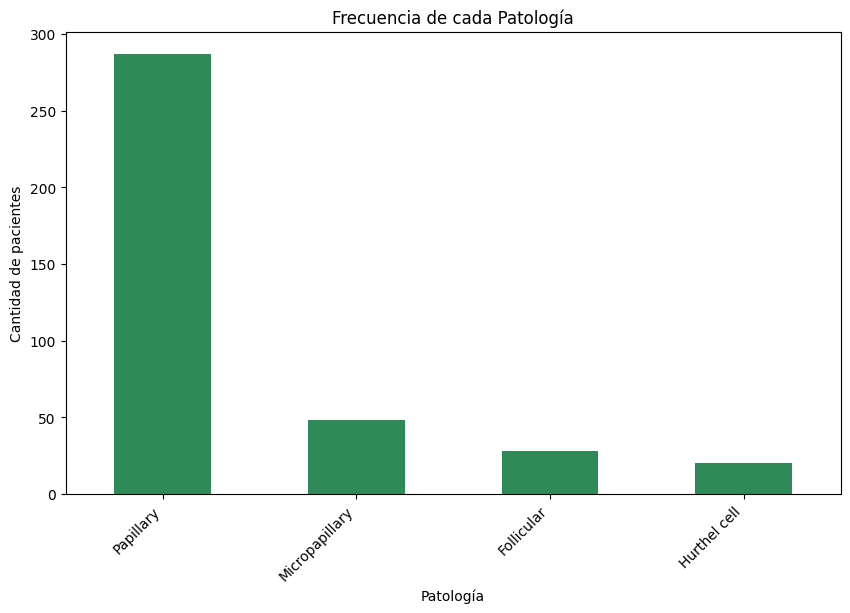

In [ ]:
# Cantidad de pacientes
num_pacientes = len(df)
print(f"La cantidad de pacientes en el dataset es: {num_pacientes}")

# Porcentaje de reaparición y tipo de patología
reaparicion = df['Recurred'].value_counts(normalize=True) * 100
print("\nPorcentaje de reaparición del cáncer de tiroides:")
print(reaparicion)

patologia_reaparicion = df.groupby('Recurred')['Pathology'].value_counts(normalize=True).unstack() * 100
print("\nPorcentaje de tipo de patología por reaparición:")
print(patologia_reaparicion,"\n")

# Gráfico de la patología más común
plt.figure(figsize=(10, 6))
df['Pathology'].value_counts().plot(kind='bar', color='SeaGreen')
plt.title('Frecuencia de cada Patología')
plt.xlabel('Patología')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=45, ha='right')
plt.show()

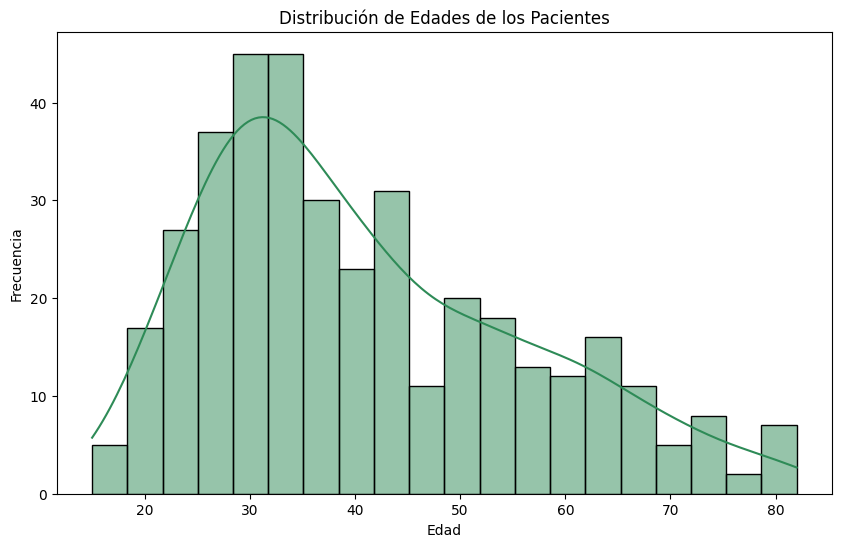

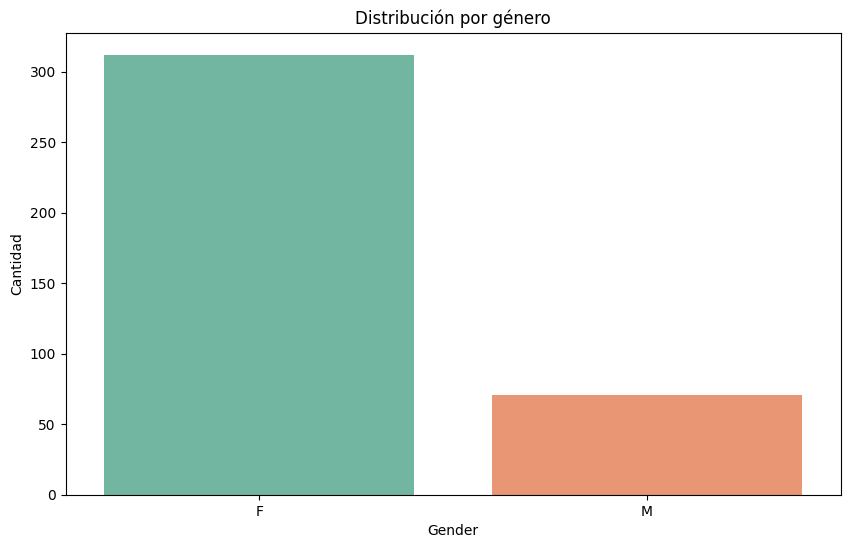

In [ ]:
# Distribución de edades
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='SeaGreen')
plt.title('Distribución de Edades de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

print(f'')

# Distribución por género
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='Gender', data=df, palette='Set2')
plt.title(f'Distribución por género')
plt.xlabel('Gender')
plt.ylabel('Cantidad')
plt.show()

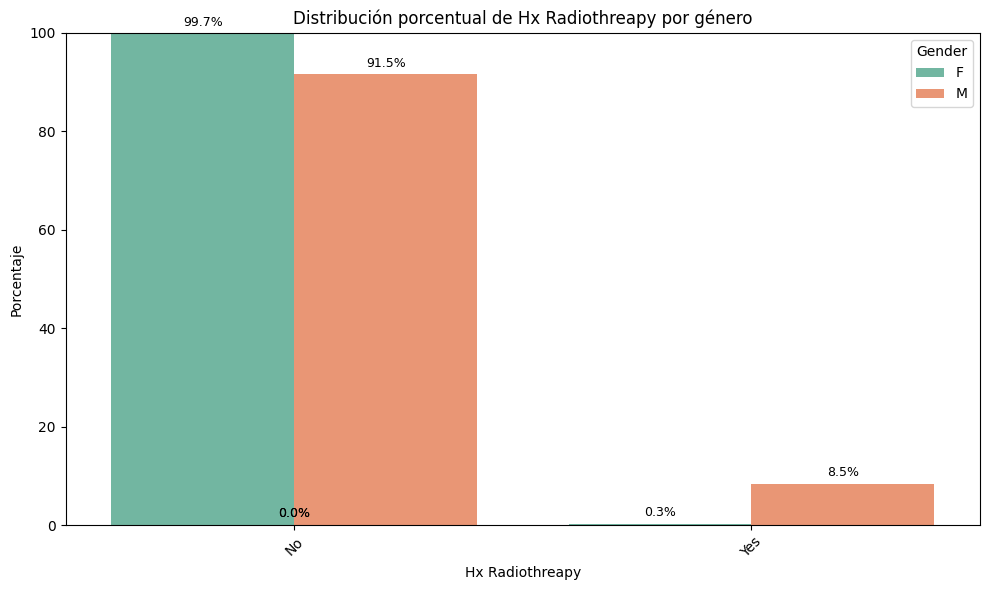

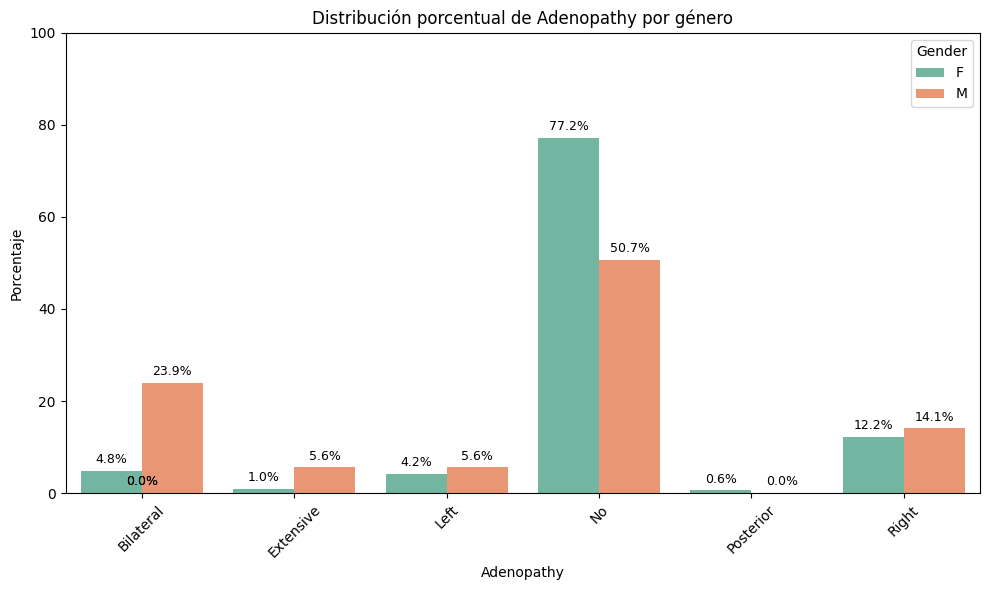

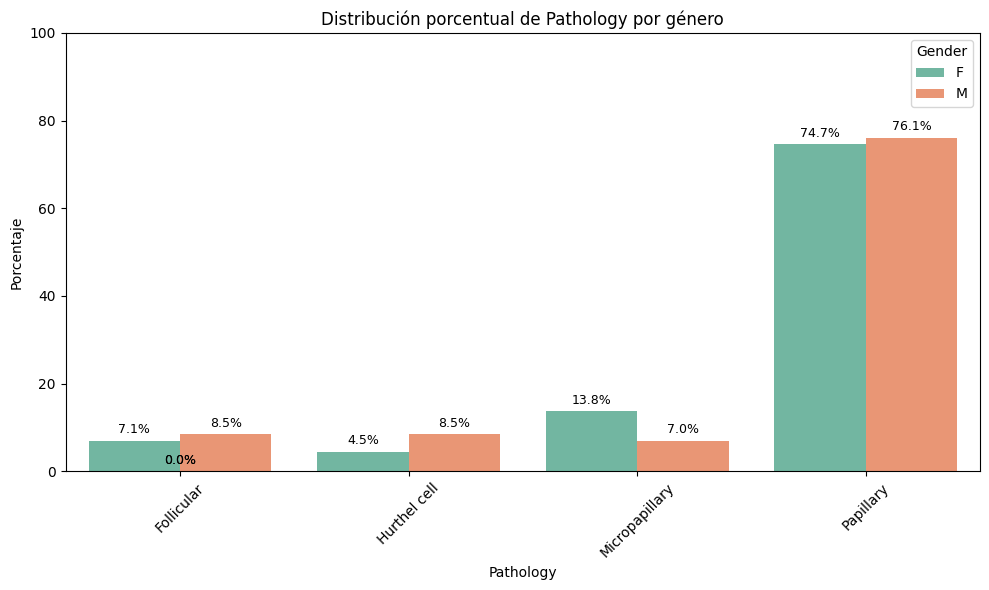

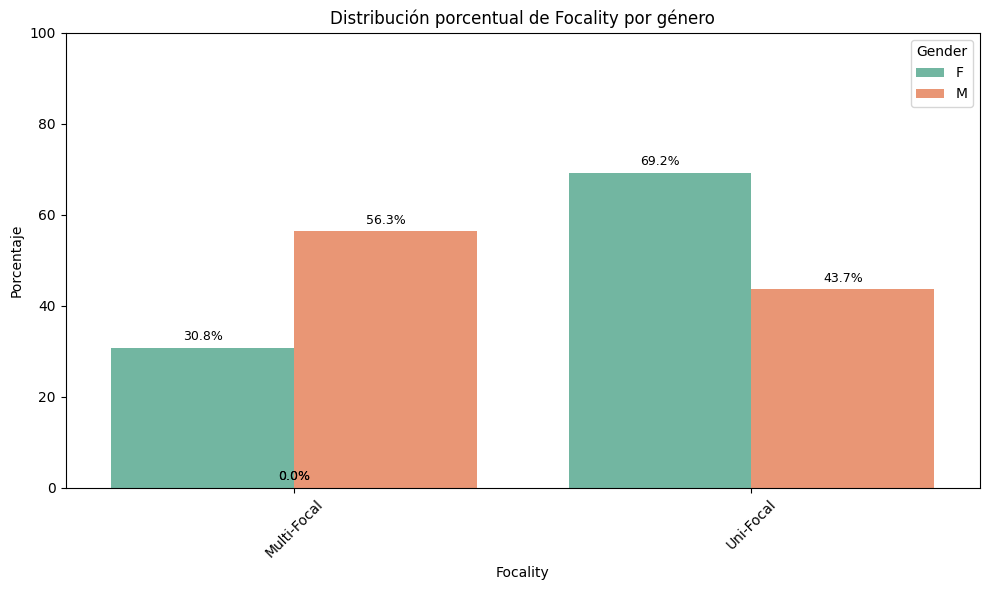

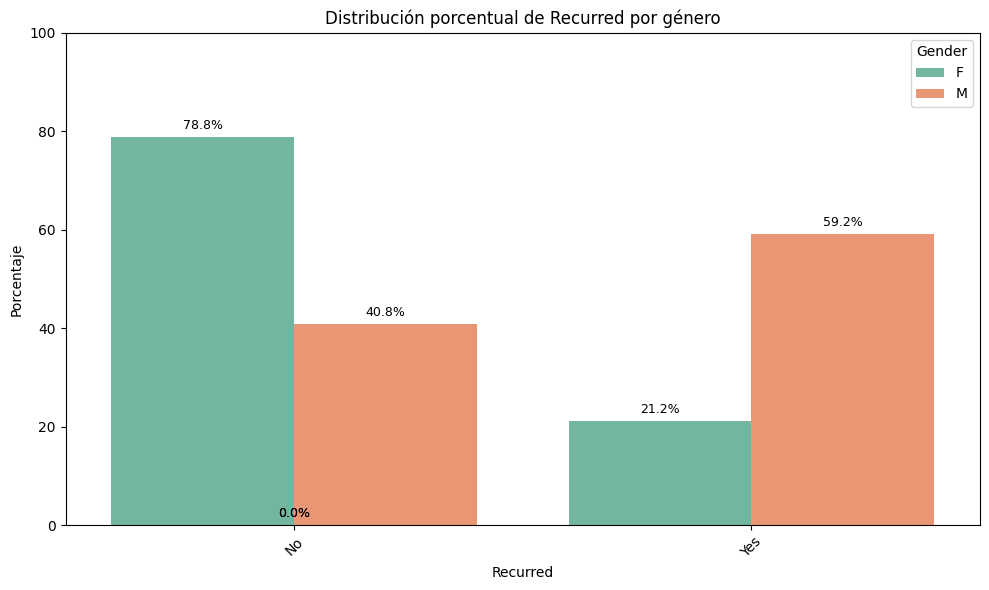

In [ ]:
for col in categoricas_nominales:
    if col != 'Gender':
        # Calcula porcentaje por fila (por género)
        porcentaje = pd.crosstab(df[col], df['Gender'], normalize='columns') * 100
        porcentaje = porcentaje.reset_index().melt(id_vars=col, var_name='Gender', value_name='Porcentaje')

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=col, y='Porcentaje', hue='Gender', data=porcentaje, palette='Set2')

        # Añadir etiquetas de porcentaje encima de cada barra
        for p in ax.patches:
            height = p.get_height()
            if not pd.isna(height):
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 1,
                    f'{height:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

        plt.title(f'Distribución porcentual de {col} por género')
        plt.ylabel('Porcentaje')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.show()

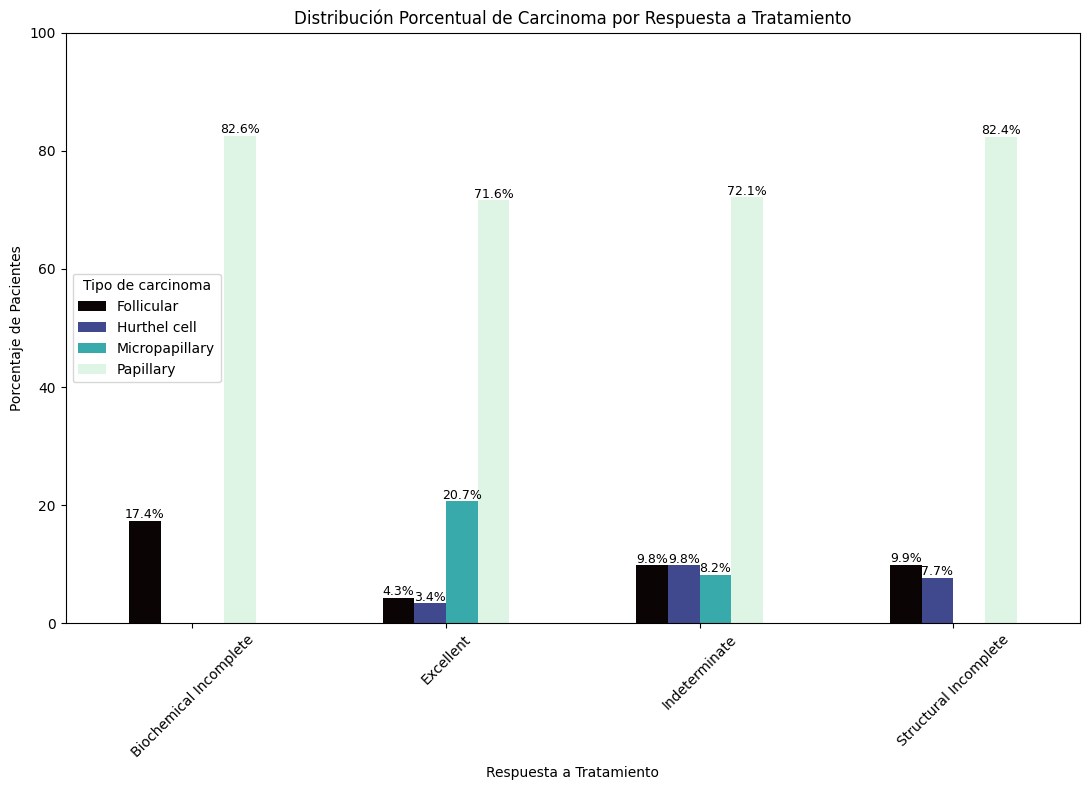

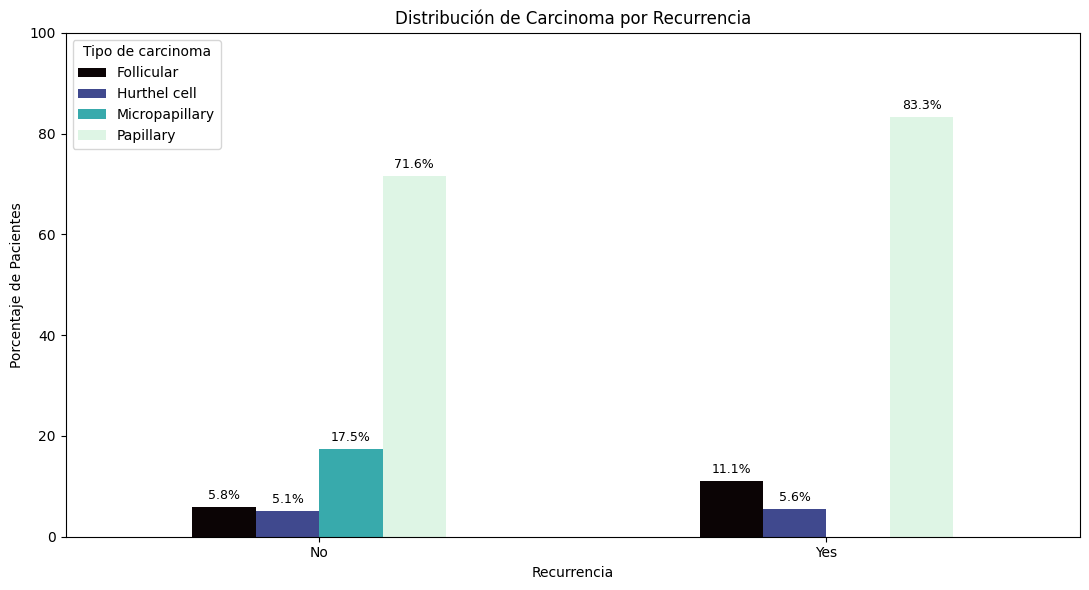

In [ ]:
# Agrupar por Response y Pathology
pathology_response = df.groupby(['Response', 'Pathology']).size().unstack(fill_value=0)
# Calcular porcentaje por fila (por cada tipo de Response)
pathology_response_percentage = pathology_response.div(pathology_response.sum(axis=1), axis=0) * 100


# Crear la figura y el gráfico con porcentajes
ax = pathology_response_percentage.plot(kind='bar', colormap='mako', figsize=(11, 8))

# Agregar etiquetas de porcentaje en cada segmento
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 1,
            f'{height:.1f}%',
            ha='center',
            va='center',
            fontsize=9,
        )

# Ajustes del gráfico
plt.title("Distribución Porcentual de Carcinoma por Respuesta a Tratamiento")
plt.xlabel("Respuesta a Tratamiento")
plt.ylabel("Porcentaje de Pacientes")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(title='Tipo de carcinoma')
plt.tight_layout()
plt.show()

#--------------------------------------------------------------------------------------------------------
print(f"")

# Agrupar por Recurred y Pathology
recurrence_pathology = df.groupby(['Recurred', 'Pathology']).size().unstack(fill_value=0)

# Calcular el porcentaje por fila (por cada tipo de Recurred)
recurrence_pathology_percentage = recurrence_pathology.div(recurrence_pathology.sum(axis=1), axis=0) * 100

# Crear el gráfico de barras
ax = recurrence_pathology_percentage.plot(kind='bar', figsize=(11, 6), colormap='mako')

# Agregar etiquetas de porcentaje en cada barra
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 1,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Ajustes del gráfico
plt.title('Distribución de Carcinoma por Reaparición')
plt.xlabel('Reaparición')
plt.ylabel('Porcentaje de Pacientes')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Tipo de carcinoma')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

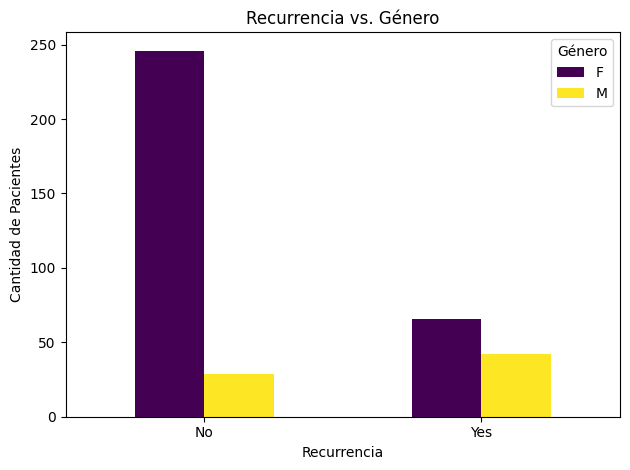

<Figure size 1000x600 with 0 Axes>

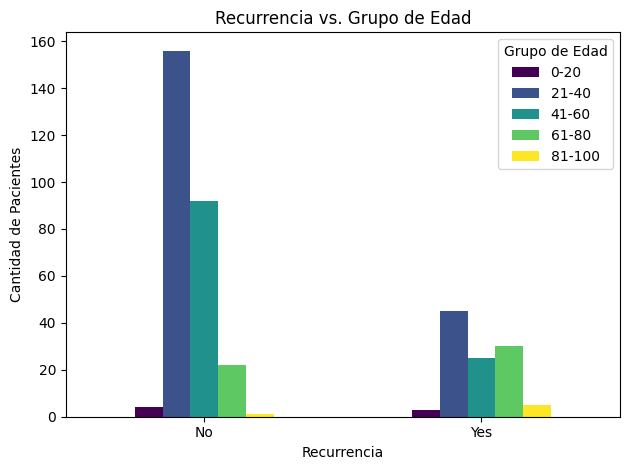

In [ ]:
# Agrupar los datos por 'Recurred' y 'Gender', luego contar las ocurrencias
recurrence_gender = df.groupby(['Recurred', 'Gender']).size().unstack(fill_value=0)

# Crear el barplot
plt.figure(figsize=(8, 6))
recurrence_gender.plot(kind='bar', stacked=False, colormap='viridis')  # Puedes cambiar el colormap si lo deseas
plt.title('Reaparición vs. Género')
plt.xlabel('Reaparición')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.tight_layout()
plt.show()

# Agrupar los datos por 'Recurred' y 'Age'
# Debido a que la edad es una variable numérica continua, primero debemos discretizarla
# Aquí se utiliza la función cut para crear grupos de edades
bins = [0, 20, 40, 60, 80, 100] # Define los rangos de edad para los grupos
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

recurrence_age = df.groupby(['Recurred', 'AgeGroup']).size().unstack(fill_value=0)

# Crear el barplot
plt.figure(figsize=(10, 6))
recurrence_age.plot(kind='bar', stacked=False, colormap='viridis')
plt.title('Recurrencia vs. Grupo de Edad')
plt.xlabel('Recurrencia')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=0)
plt.legend(title='Grupo de Edad')
plt.tight_layout()
plt.show()
